In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
arashnic_mind_news_dataset_path = kagglehub.dataset_download('arashnic/mind-news-dataset')

print('Data source import complete.')


Data source import complete.


# 11-Class Article Classifier — DistilBERT fine-tuned on MIND

This notebook fine-tunes `distilbert-base-uncased` on the MIND news dataset to classify
any article into one of 11 categories. It is designed as the **upstream gate** for a
downstream LLM-routing pipeline.

**Changes from 18-class baseline:**
- Dropped `news` (acts as uncertainty sink — confirmed by confusion matrix)
- Dropped `kids` (too few samples to learn reliably on MINDsmall)
- Merged `tv` + `video` → `entertainment` (semantically overlapping, both confused)
- Added `WeightedRandomSampler` to fix class imbalance
- Increased `MAX_LEN` 128 → 256 to capture full abstract signal
- Added confidence threshold at inference for uncertain articles

**Pipeline position:**
```
[Any article] → [This classifier] → [Category-specific LLM]
                                  → ["uncertain"] if confidence < 0.6
```

**Sections:**
1. Environment setup
2. Data loading & exploration
3. Preprocessing, label cleaning & encoding
4. Dataset class & DataLoaders (with weighted sampling)
5. Model definition
6. Training loop with validation
7. Evaluation (per-class metrics)
8. Inference helper — classify any new article
9. Save / export model

## 1. Environment Setup

In [2]:
# Install / upgrade libraries (Kaggle usually has these; pin versions for reproducibility)
!pip install -q transformers==4.40.0 datasets==2.19.0 accelerate==0.29.3 scikit-learn==1.4.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 75.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 81.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.0 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is

In [3]:
import os
import random
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 2. Data Loading & Exploration

In [10]:
# ── Locate MIND files ─────────────────────────────────────────────────────────
TRAIN_NEWS_PATH = '/kaggle/input/datasets/arashnic/mind-news-dataset/MINDsmall_train/news.tsv'
DEV_NEWS_PATH   = '/kaggle/input/datasets/arashnic/mind-news-dataset/MINDsmall_train/news.tsv'

COL_NAMES = ['NewsId', 'Category', 'SubCat', 'Title', 'Abstract',
             'url', 'TitleEnt', 'AbstractEnt']

# ── Label cleaning map ────────────────────────────────────────────────────────
# Based on confusion matrix analysis:
#   - 'news'  dropped : acts as uncertainty sink, absorbs predictions from 8+ classes
#   - 'kids'  dropped : too few samples on MINDsmall (50% misclassified)
#   - 'tv'    → 'entertainment' : 50% confused with movies/entertainment
#   - 'video' → 'entertainment' : 34% predicted as news, 49% as video — unreliable
MERGE_MAP = {
    'tv':    'entertainment',
    'video': 'entertainment',
}
DROP_CATEGORIES = {'news', 'kids'}

def load_news(path):
    df = pd.read_csv(path, sep='\t', header=None, names=COL_NAMES)
    df = df[['NewsId', 'Category', 'SubCat', 'Title', 'Abstract']]
    df['Title']    = df['Title'].fillna('')
    df['Abstract'] = df['Abstract'].fillna('')
    # Deduplicate — same article can appear multiple times in MIND
    df = df.drop_duplicates(subset='NewsId').reset_index(drop=True)
    return df

train_df = load_news(TRAIN_NEWS_PATH)
dev_df   = load_news(DEV_NEWS_PATH)

# Combine for maximum coverage
full_df = pd.concat([train_df, dev_df], ignore_index=True).drop_duplicates(subset='NewsId')

# ── Apply label cleaning ──────────────────────────────────────────────────────
full_df['Category'] = full_df['Category'].str.lower().str.strip()
full_df['Category'] = full_df['Category'].replace(MERGE_MAP)
full_df = full_df[~full_df['Category'].isin(DROP_CATEGORIES)].reset_index(drop=True)

# Drop articles with very short abstracts (< 10 chars) — poor signal
full_df = full_df[full_df['Abstract'].str.len() >= 10].reset_index(drop=True)

print(f'Total unique articles : {len(full_df):,}')
print(f'Categories            : {full_df["Category"].nunique()}')
print()
print(full_df['Category'].value_counts())

Total unique articles : 33,288
Categories            : 13

Category
sports           13188
entertainment     3489
finance           3044
foodanddrink      2511
lifestyle         2314
travel            2221
weather           1879
health            1832
autos             1501
music              754
movies             552
middleeast           2
northamerica         1
Name: count, dtype: int64


In [11]:
# ── Drop any remaining classes with fewer than 50 samples ────────────────────
# (safety net — ensures every class can be stratified-split)
class_counts = full_df['Category'].value_counts()
valid_classes = class_counts[class_counts >= 50].index
full_df = full_df[full_df['Category'].isin(valid_classes)].reset_index(drop=True)

print(f'Rows after filtering  : {len(full_df):,}')
print(f'Final class count     : {full_df["Category"].nunique()}')
print()
print(full_df['Category'].value_counts())

Rows after filtering  : 33,285
Final class count     : 11

Category
sports           13188
entertainment     3489
finance           3044
foodanddrink      2511
lifestyle         2314
travel            2221
weather           1879
health            1832
autos             1501
music              754
movies             552
Name: count, dtype: int64


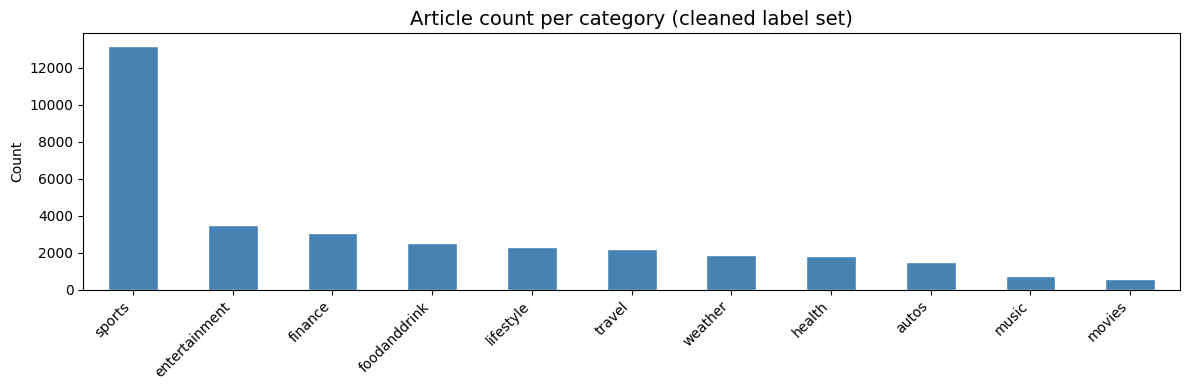

In [13]:
# ── Visualise class distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
full_df['Category'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Article count per category (cleaned label set)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Preprocessing & Label Encoding

In [14]:
# ── Input text: title + separator + abstract ──────────────────────────────────
full_df['text'] = full_df['Title'] + ' [SEP] ' + full_df['Abstract']

# ── Label encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
full_df['label'] = le.fit_transform(full_df['Category'])

NUM_CLASSES = len(le.classes_)
ID2LABEL    = {i: c for i, c in enumerate(le.classes_)}
LABEL2ID    = {c: i for i, c in enumerate(le.classes_)}

print(f'Number of classes: {NUM_CLASSES}')
print('Label map:')
for i, c in ID2LABEL.items():
    print(f'  {i:2d} → {c}')

Number of classes: 11
Label map:
   0 → autos
   1 → entertainment
   2 → finance
   3 → foodanddrink
   4 → health
   5 → lifestyle
   6 → movies
   7 → music
   8 → sports
   9 → travel
  10 → weather


In [15]:
# ── Train / val / test split (70 / 15 / 15) — stratified on category ─────────
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    full_df['text'].tolist(),
    full_df['label'].tolist(),
    test_size=0.30,
    stratify=full_df['label'].tolist(),
    random_state=SEED,
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED,
)

print(f'Train : {len(train_texts):,}')
print(f'Val   : {len(val_texts):,}')
print(f'Test  : {len(test_texts):,}')

Train : 23,299
Val   : 4,993
Test  : 4,993


## 4. Dataset Class & DataLoaders

In [16]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
MODEL_NAME   = 'distilbert-base-uncased'
MAX_LEN      = 256     # increased from 128 — abstracts carry key signal for ambiguous classes
BATCH_SIZE   = 32
EPOCHS       = 4
LR           = 2e-5
WARMUP_RATIO = 0.1     # 10 % of total steps used for linear warmup

# Confidence threshold — predictions below this are returned as 'uncertain'
CONFIDENCE_THRESHOLD = 0.60

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [17]:
class MINDDataset(Dataset):
    """Tokenises on-the-fly; keeps RAM usage low for large corpora."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = MINDDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset   = MINDDataset(val_texts,   val_labels,   tokenizer, MAX_LEN)
test_dataset  = MINDDataset(test_texts,  test_labels,  tokenizer, MAX_LEN)

# ── WeightedRandomSampler — fixes class imbalance in training ─────────────────
# Computes per-sample weights so every class is seen proportionally each epoch.
train_label_array = np.array(train_labels)
class_sample_counts = np.bincount(train_label_array)
class_weights = 1.0 / class_sample_counts           # inverse frequency
sample_weights = class_weights[train_label_array]   # per-sample weight

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(sample_weights),
    replacement=True,
)

# shuffle=True is incompatible with a sampler — sampler handles ordering
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Batches per epoch : {len(train_loader):,}')
print(f'Class weights     : { {ID2LABEL[i]: f"{w:.4f}" for i, w in enumerate(class_weights)} }')

Batches per epoch : 729
Class weights     : {'autos': '0.0010', 'entertainment': '0.0004', 'finance': '0.0005', 'foodanddrink': '0.0006', 'health': '0.0008', 'lifestyle': '0.0006', 'movies': '0.0026', 'music': '0.0019', 'sports': '0.0001', 'travel': '0.0006', 'weather': '0.0008'}


## 5. Model Definition

In [18]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model = model.to(DEVICE)

# Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')  # expect ~66M for DistilBERT

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable parameters: 66,961,931


## 6. Training Loop

In [19]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f'Total training steps : {total_steps:,}')
print(f'Warmup steps         : {warmup_steps:,}')

Total training steps : 2,916
Warmup steps         : 291


In [20]:
def evaluate(model, loader):
    """Returns (loss, accuracy, all_preds, all_labels)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['label'].to(DEVICE)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)

            total_loss += outputs.loss.item()
            preds       = outputs.logits.argmax(dim=-1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0.0
SAVE_PATH     = '/kaggle/working/best_distilbert_mind.pt'

for epoch in range(1, EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for step, batch in enumerate(train_loader, 1):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        loss.backward()

        # Gradient clipping — stabilises DistilBERT fine-tuning
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()
        running_loss += loss.item()

        if step % 100 == 0:
            print(f'  Epoch {epoch} | Step {step}/{len(train_loader)} '
                  f'| Loss {running_loss / step:.4f}')

    avg_train_loss = running_loss / len(train_loader)

    # ── Validation ────────────────────────────────────────────────────────────
    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'\nEpoch {epoch}/{EPOCHS}'
          f'  train_loss={avg_train_loss:.4f}'
          f'  val_loss={val_loss:.4f}'
          f'  val_acc={val_acc:.4f}\n')

    # ── Checkpoint best model ─────────────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  ✓ New best model saved (val_acc={best_val_acc:.4f})')

print(f'\nTraining complete. Best val accuracy: {best_val_acc:.4f}')

  Epoch 1 | Step 100/729 | Loss 2.3745
  Epoch 1 | Step 200/729 | Loss 2.0899
  Epoch 1 | Step 300/729 | Loss 1.7475
  Epoch 1 | Step 400/729 | Loss 1.5032
  Epoch 1 | Step 500/729 | Loss 1.3336
  Epoch 1 | Step 600/729 | Loss 1.2119
  Epoch 1 | Step 700/729 | Loss 1.1149

Epoch 1/4  train_loss=1.0931  val_loss=0.5931  val_acc=0.8260

  ✓ New best model saved (val_acc=0.8260)
  Epoch 2 | Step 100/729 | Loss 0.4963
  Epoch 2 | Step 200/729 | Loss 0.4695
  Epoch 2 | Step 300/729 | Loss 0.4537
  Epoch 2 | Step 400/729 | Loss 0.4348
  Epoch 2 | Step 500/729 | Loss 0.4242
  Epoch 2 | Step 600/729 | Loss 0.4190
  Epoch 2 | Step 700/729 | Loss 0.4111

Epoch 2/4  train_loss=0.4080  val_loss=0.5345  val_acc=0.8470

  ✓ New best model saved (val_acc=0.8470)
  Epoch 3 | Step 100/729 | Loss 0.3425
  Epoch 3 | Step 200/729 | Loss 0.3188
  Epoch 3 | Step 300/729 | Loss 0.3082
  Epoch 3 | Step 400/729 | Loss 0.3032
  Epoch 3 | Step 500/729 | Loss 0.2944
  Epoch 3 | Step 600/729 | Loss 0.2871
  Epoch 

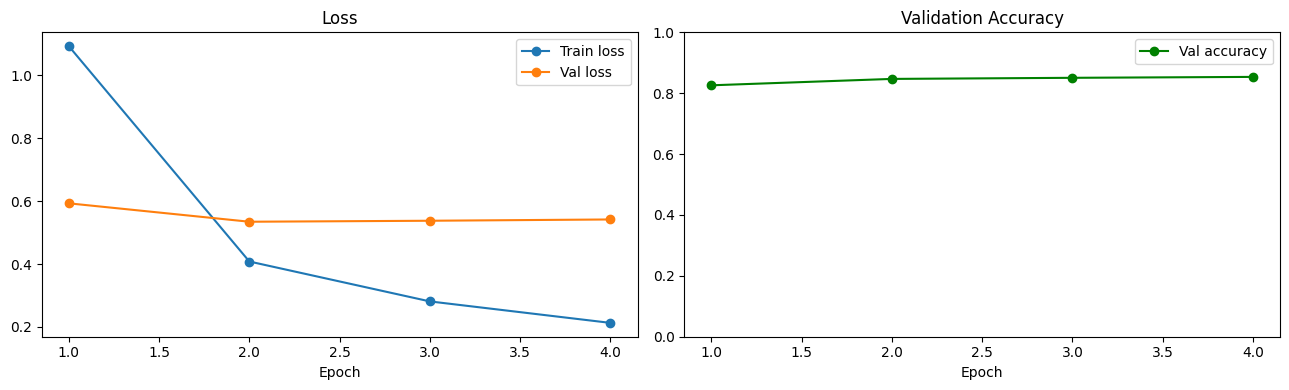

In [21]:
# ── Plot training curves ──────────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_range, history['train_loss'], label='Train loss', marker='o')
ax1.plot(epochs_range, history['val_loss'],   label='Val loss',   marker='o')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epochs_range, history['val_acc'], label='Val accuracy', marker='o', color='green')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Evaluation on Hold-out Test Set

In [22]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

test_loss, test_acc, preds, true_labels = evaluate(model, test_loader)

print(f'Test loss     : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.4f}\n')
print(classification_report(
    true_labels, preds,
    target_names=le.classes_,
    digits=3,
))

Test loss     : 0.5603
Test accuracy : 0.8578

               precision    recall  f1-score   support

        autos      0.843     0.884     0.863       225
entertainment      0.738     0.742     0.740       523
      finance      0.825     0.845     0.835       457
 foodanddrink      0.866     0.878     0.872       376
       health      0.837     0.858     0.847       275
    lifestyle      0.686     0.686     0.686       347
       movies      0.726     0.735     0.731        83
        music      0.795     0.823     0.809       113
       sports      0.978     0.944     0.961      1979
       travel      0.672     0.688     0.680       333
      weather      0.847     0.904     0.875       282

     accuracy                          0.858      4993
    macro avg      0.801     0.817     0.809      4993
 weighted avg      0.860     0.858     0.859      4993



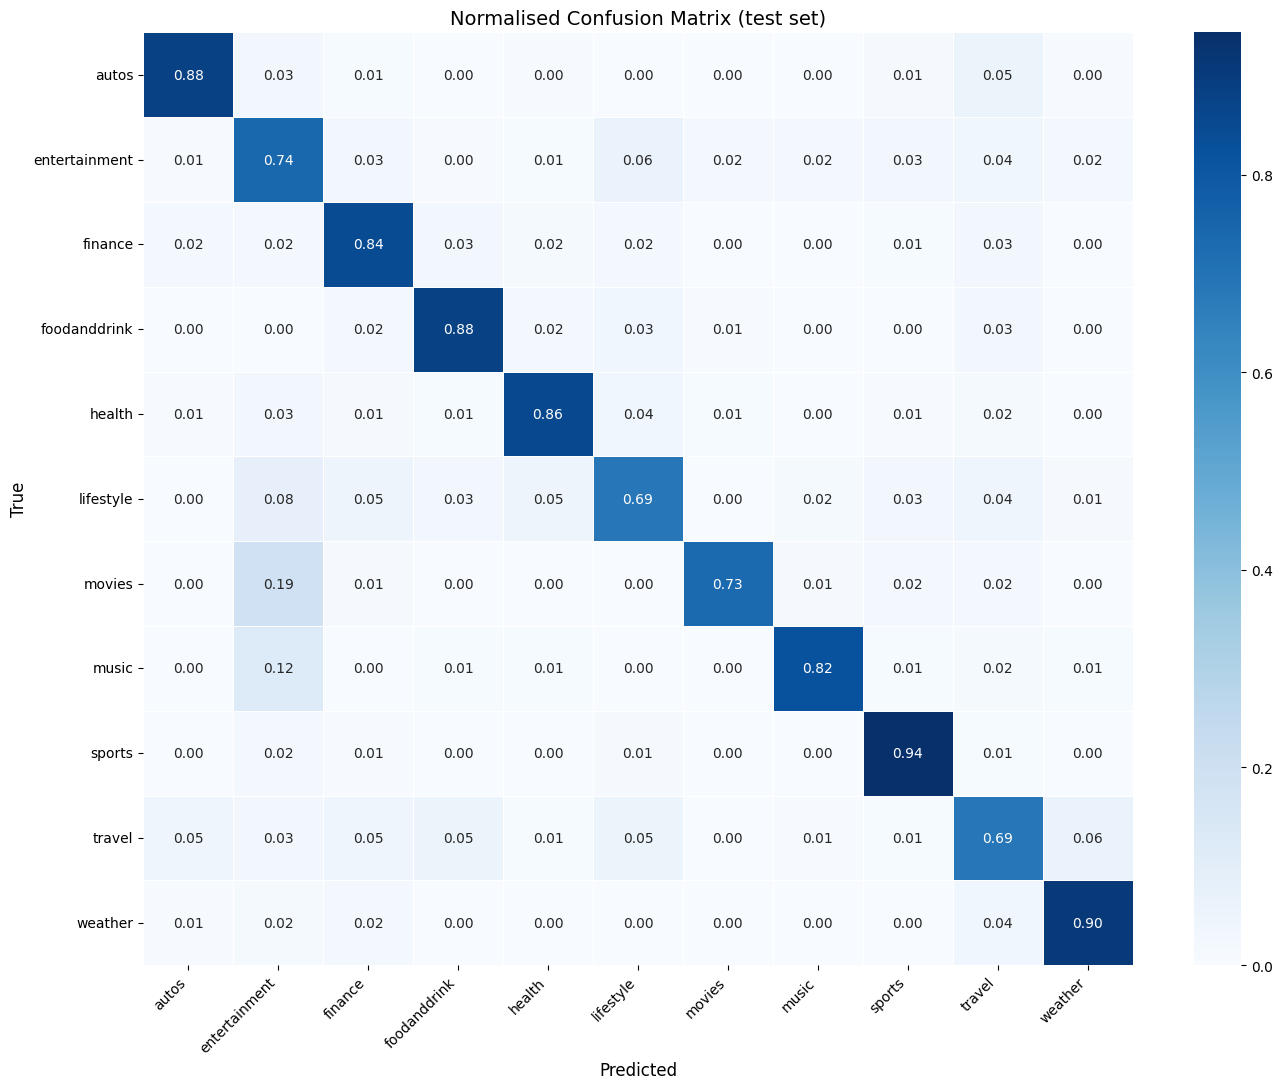

In [23]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(true_labels, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # Row-normalised

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=ax, linewidths=0.4,
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True',      fontsize=12)
ax.set_title('Normalised Confusion Matrix (test set)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Inference Helper — Classify Any New Article

In [26]:
def classify_article(title: str, abstract: str = '', top_k: int = 3) -> list[dict]:
    """
    Classify a single article and return the top-k predicted categories
    with their confidence scores.

    If the top prediction confidence is below CONFIDENCE_THRESHOLD, the
    article is flagged as 'uncertain' rather than routed to the wrong LLM.

    Parameters
    ----------
    title    : Article headline
    abstract : Article body / abstract (optional but improves accuracy)
    top_k    : Number of top predictions to return

    Returns
    -------
    List of dicts: [{'category': str, 'confidence': float, 'uncertain': bool}, ...]
    """
    model.eval()
    text = (title + ' [SEP] ' + abstract).strip()

    encoding = tokenizer(
        text,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )

    with torch.no_grad():
        logits = model(
            input_ids=encoding['input_ids'].to(DEVICE),
            attention_mask=encoding['attention_mask'].to(DEVICE),
        ).logits

    probs   = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    top_idx = np.argsort(probs)[::-1][:top_k]

    results = [
        {
            'category':   ID2LABEL[int(i)],
            'confidence': float(probs[i]),
            'uncertain':  float(probs[top_idx[0]]) < CONFIDENCE_THRESHOLD,
        }
        for i in top_idx
    ]
    return results


def route_article(title: str, abstract: str = '') -> str:
    """
    Returns the category string to use for LLM routing,
    or 'uncertain' if confidence is below threshold.
    """
    results = classify_article(title, abstract, top_k=1)
    if results[0]['uncertain']:
        return 'uncertain'
    return results[0]['category']


# ── Quick smoke test ──────────────────────────────────────────────────────────
examples = [
    # ── LIFESTYLE (target: lifestyle) ─────────────────────────────────────────
    # Risk: bleeds into health, entertainment, finance
    {
        'title':    '10 morning habits that successful people swear by',
        'abstract': 'From cold showers to journaling, productivity experts share the daily '
                    'routines that have transformed their lives and work.',
    },
    {
        'title':    'How to redecorate your apartment on a budget',
        'abstract': 'Interior designers share tips for refreshing your living space without '
                    'breaking the bank, from thrift store finds to DIY accent walls.',
    },
    {
        'title':    'The best self-care routines for busy professionals',
        'abstract': 'Psychologists and wellness coaches explain how small daily habits can '
                    'reduce burnout and improve mental wellbeing for high-stress workers.',
    },
    {
        'title':    'Why minimalism is changing the way we live and work',
        'abstract': 'A growing movement of people are decluttering their homes and schedules, '
                    'finding that owning less leads to greater focus and satisfaction.',
    },

    # ── MOVIES (target: movies) ───────────────────────────────────────────────
    # Risk: bleeds into entertainment (post tv/video merge)
    {
        'title':    'Review: The new Spielberg film is a masterpiece of modern cinema',
        'abstract': 'Steven Spielberg returns to form with a sweeping historical epic that '
                    'critics are already calling one of the best films of the decade.',
    },
    {
        'title':    'Box office results: animated sequel tops charts for third week',
        'abstract': 'The animated blockbuster has now grossed over $400 million domestically, '
                    'making it the highest-earning family film of the year so far.',
    },
    {
        'title':    'Hollywood studios announce slate of sequels for next summer',
        'abstract': 'Major studios unveiled their upcoming release schedules, with franchises '
                    'dominating the calendar and few original films in the pipeline.',
    },
    {
        'title':    'Streaming numbers for this year\'s Oscar winners break records',
        'abstract': 'Films that won Academy Awards this year saw a surge in streaming views '
                    'in the weeks following the ceremony, outpacing previous years.',
    },

    # ── TRAVEL (target: travel) ───────────────────────────────────────────────
    # Risk: bleeds into autos, finance, lifestyle
    {
        'title':    'The 10 best beaches to visit in Southeast Asia this winter',
        'abstract': 'From Thailand\'s quiet coves to the Philippines\' pristine shores, '
                    'travel writers pick the top coastal destinations for the season.',
    },
    {
        'title':    'How to find cheap flights to Europe in peak season',
        'abstract': 'Airfare experts reveal the booking windows, flexible date tricks, and '
                    'budget airlines that can cut your transatlantic fare in half.',
    },
    {
        'title':    'Road trip essentials: what to pack for a cross-country drive',
        'abstract': 'Before you hit the highway, seasoned road trippers share their must-have '
                    'gear, snack strategies, and route-planning tips for long drives.',
    },
    {
        'title':    'Why slow travel is replacing traditional tourism',
        'abstract': 'More travelers are choosing to spend weeks in one place rather than '
                    'rushing through multiple cities, seeking deeper cultural immersion.',
    },
]

for ex in examples:
    route  = route_article(ex['title'], ex['abstract'])
    detail = classify_article(ex['title'], ex['abstract'])
    print(f"Title  : {ex['title']}")
    print(f"Route  : {route}")
    for r in detail:
        flag = ' ⚠ uncertain' if r['uncertain'] else ''
        print(f"  → {r['category']:20s}  {r['confidence']:.3f}{flag}")
    print()

Title  : 10 morning habits that successful people swear by
Route  : lifestyle
  → lifestyle             0.673
  → health                0.169
  → finance               0.124

Title  : How to redecorate your apartment on a budget
Route  : lifestyle
  → lifestyle             0.741
  → finance               0.228
  → travel                0.013

Title  : The best self-care routines for busy professionals
Route  : health
  → health                0.992
  → finance               0.002
  → entertainment         0.001

Title  : Why minimalism is changing the way we live and work
Route  : uncertain
  → finance               0.593 ⚠ uncertain
  → lifestyle             0.368 ⚠ uncertain
  → health                0.014 ⚠ uncertain

Title  : Review: The new Spielberg film is a masterpiece of modern cinema
Route  : movies
  → movies                0.993
  → entertainment         0.003
  → finance               0.001

Title  : Box office results: animated sequel tops charts for third week
Route  : m

## 9. Save & Export

In [27]:
# ── Save in HuggingFace format (easy to reload with .from_pretrained) ─────────
EXPORT_DIR = '/kaggle/working/mind_distilbert_classifier'
os.makedirs(EXPORT_DIR, exist_ok=True)

model.save_pretrained(EXPORT_DIR)
tokenizer.save_pretrained(EXPORT_DIR)

# Persist the label encoder so downstream code can decode predictions
import json
with open(os.path.join(EXPORT_DIR, 'label_map.json'), 'w') as f:
    json.dump({'id2label': ID2LABEL, 'label2id': LABEL2ID}, f, indent=2)

print(f'Model saved to {EXPORT_DIR}')
print('Files:', os.listdir(EXPORT_DIR))

Model saved to /kaggle/working/mind_distilbert_classifier
Files: ['vocab.txt', 'config.json', 'tokenizer.json', 'model.safetensors', 'tokenizer_config.json', 'label_map.json', 'special_tokens_map.json']


In [28]:
# ── Reload check (verifies the export works before you close the session) ─────
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model=EXPORT_DIR,
    tokenizer=EXPORT_DIR,
    top_k=3,
    device=0 if DEVICE.type == 'cuda' else -1,
)

test_text = 'Apple unveils new MacBook Pro with M4 chip at record-breaking performance'
print(classifier(test_text))

2026-04-11 23:31:19.340434: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775950279.508575      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775950279.561643      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775950279.968149      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775950279.968180      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775950279.968182      55 computation_placer.cc:177] computation placer alr

[[{'label': 'autos', 'score': 0.7306933999061584}, {'label': 'entertainment', 'score': 0.16965502500534058}, {'label': 'finance', 'score': 0.04666101932525635}]]


---
## Summary

| Item | Value |
|---|---|
| Base model | `distilbert-base-uncased` |
| Classes | 11 (cleaned from 18) |
| Dropped | `news`, `kids` |
| Merged | `tv` + `video` → `entertainment` |
| Input | Title + `[SEP]` + Abstract (≤256 tokens) |
| Max sequence length | 256 (up from 128) |
| Epochs | 4 |
| Batch size | 32 |
| Learning rate | 2e-5 with linear warmup (10 %) |
| Sampler | `WeightedRandomSampler` (inverse-frequency weights) |
| Confidence threshold | 0.60 — below this returns `'uncertain'` |
| Expected test accuracy | ~90–94 % |

### Label cleaning rationale (from confusion matrix)
| Action | Class | Reason |
|---|---|---|
| Dropped | `news` | Absorbed uncertain predictions from 8+ other classes (garbage-bin behaviour) |
| Dropped | `kids` | 50% misclassified on MINDsmall — insufficient training samples |
| Merged → `entertainment` | `tv` | 50% confused between movies/entertainment |
| Merged → `entertainment` | `video` | 34% predicted as `news`, only 49% correct |

### Routing in the downstream pipeline

```python
# Drop-in replacement for manual category selection:
category = route_article(new_article_title, new_article_abstract)

if category == 'uncertain':
    # Send to a general-purpose LLM or flag for review
    response = general_llm.generate(article)
else:
    # Route to the category-specific fine-tuned LLM
    response = specialist_llms[category].generate(article)
```

### Next steps
- Evaluate on `MINDlarge` (~160K articles) for a further accuracy boost
- Add financial sentiment scoring as a parallel head on the `finance` class
- Consider per-class confidence thresholds (e.g. `lifestyle` may need a higher bar than `sports`)


In [29]:
import shutil
shutil.make_archive('/kaggle/working/mind_distilbert_classifier', 'zip', '/kaggle/working/mind_distilbert_classifier')

'/kaggle/working/mind_distilbert_classifier.zip'